In [2]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [3]:
import pandas as pd
from src.get_data import load_data
from src.train.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.train.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.train.training import run_experiment
from src.visualisation import (
    compare_models_for_cell,
    compare_r2_across_cells,
    compare_models_pairwise_r2,
    journal_plot_pack,
)
from src.train.poisson_nn.nn_models import CNNExtractor, RNNExtractor
from sklearn.preprocessing import StandardScaler

In [ ]:
BASE_MODEL_DIR = "../resources/models/real"
BASE_RESULTS_DIR = "../resources/results/real"
FORCE_EXPERIMENTS = True

# Real data
X, Y, cell_ids, rec_ids = load_data("../resources/data/real/Temi_Data.mat")

In [5]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((14, 1657180), (1657180,), (1657180,), (1657180,))

### Baseline models (GLM and XGBoost)

In [6]:
# Baseline models: Poisson GLM with grid search
glm_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\real\GLM.pkl


In [7]:
# Fit without grid search
glm_nogs_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": False, "alpha": 0.1},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\real\GLM.pkl


In [8]:
glm_results["best_params"]

{1: {'alpha': 0.1},
 2: {'alpha': 0.1},
 3: {'alpha': 0.1},
 4: {'alpha': 0.1},
 5: {'alpha': 0.1},
 6: {'alpha': 0.1},
 7: {'alpha': 0.1},
 8: {'alpha': 0.1},
 9: {'alpha': 0.1},
 10: {'alpha': 0.1},
 11: {'alpha': 0.1},
 12: {'alpha': 0.1},
 13: {'alpha': 0.1},
 14: {'alpha': 0.1},
 15: {'alpha': 0.1},
 16: {'alpha': 0.1},
 17: {'alpha': 0.1},
 18: {'alpha': 0.1},
 19: {'alpha': 0.1},
 20: {'alpha': 0.1},
 21: {'alpha': 0.1},
 22: {'alpha': 0.1},
 23: {'alpha': 0.1},
 24: {'alpha': 0.1},
 25: {'alpha': 0.1},
 26: {'alpha': 0.1},
 27: {'alpha': 0.1},
 28: {'alpha': 0.1},
 29: {'alpha': 0.1},
 30: {'alpha': 0.1},
 31: {'alpha': 0.1},
 32: {'alpha': 0.1},
 33: {'alpha': 0.1},
 34: {'alpha': 0.1},
 35: {'alpha': 0.1},
 36: {'alpha': 0.1},
 37: {'alpha': 0.1},
 38: {'alpha': 0.1},
 39: {'alpha': 0.1},
 40: {'alpha': 0.1},
 41: {'alpha': 0.1},
 42: {'alpha': 0.1},
 43: {'alpha': 0.1},
 44: {'alpha': 0.1},
 45: {'alpha': 0.1},
 46: {'alpha': 0.1},
 47: {'alpha': 0.1},
 48: {'alpha': 0.1},
 

In [9]:
# Poisson XGBoost with grid search
xgboost_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\real\XGBoost.pkl


In [10]:
# Poisson XGBoost without grid search
xgboost_nogs_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": False},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\real\XGBoost.pkl


In [11]:
xgboost_results["best_params"]

{1: {'objective': 'count:poisson',
  'max_depth': 4,
  'learning_rate': 0.05,
  'n_estimators': 300,
  'subsample': 0.8,
  'colsample_bytree': 0.8,
  'tree_method': 'hist'},
 2: {'objective': 'count:poisson',
  'max_depth': 4,
  'learning_rate': 0.05,
  'n_estimators': 300,
  'subsample': 0.8,
  'colsample_bytree': 0.8,
  'tree_method': 'hist'},
 3: {'objective': 'count:poisson',
  'max_depth': 4,
  'learning_rate': 0.05,
  'n_estimators': 300,
  'subsample': 0.8,
  'colsample_bytree': 0.8,
  'tree_method': 'hist'},
 4: {'objective': 'count:poisson',
  'max_depth': 4,
  'learning_rate': 0.05,
  'n_estimators': 300,
  'subsample': 0.8,
  'colsample_bytree': 0.8,
  'tree_method': 'hist'},
 5: {'objective': 'count:poisson',
  'max_depth': 4,
  'learning_rate': 0.05,
  'n_estimators': 300,
  'subsample': 0.8,
  'colsample_bytree': 0.8,
  'tree_method': 'hist'},
 6: {'objective': 'count:poisson',
  'max_depth': 4,
  'learning_rate': 0.05,
  'n_estimators': 300,
  'subsample': 0.8,
  'colsam

### Extractor factory

In [12]:
def make_extractor(extractor_name, n_features):
    if extractor_name == "CNN":
        return CNNExtractor(
            n_features=n_features,
            channels=16,
            kernel=3,
            num_layers=3,
        )
    elif extractor_name == "RNN":
        return RNNExtractor(
            n_features=n_features,
            hidden_dim=32,
            num_layers=2,
        )
    elif extractor_name == "MLP":
        return None
    else:
        raise ValueError(f"Unknown extractor_name: {extractor_name}")


extractor_names = ["MLP", "CNN", "RNN"]

### Per-cell Neural Networks (MLP + CNN + RNN, GS + No-GS)

In [ ]:
nn_model_param_grid_base = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],
}

percell_results = {name: {} for name in extractor_names}

# Grid-search versions
for name in extractor_names:
    print(f"\n=== Per-Cell NN (GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        model_param_grid = nn_model_param_grid_base
    else:
        model_param_grid = {"extractor": [extractor]}

    res = run_experiment(
        f"NN-PerCell-{name}",
        fit_poisson_nn,
        {
            "batch_size": "auto",
            "epochs": 30,
            "grid_search": True,
            "k_folds": 2,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": nn_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    percell_results[name]["GS"] = res


=== Per-Cell NN (GS) with MLP extractor ===


KeyboardInterrupt: 

In [ ]:
# No-grid-search versions (fixed extractor)
for name in extractor_names:
    print(f"\n=== Per-Cell NN (No GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        # MLP: use fixed hidden_sizes and l1_lambda as in original
        kwargs = {
            "batch_size": "auto",
            "hidden_sizes": [64, 32],
            "l1_lambda": 0.0,
            "grid_search": False,
            "verbose": True,
        }
    else:
        # CNN/RNN: fixed extractor, no grid search
        kwargs = {
            "batch_size": "auto",
            "model_param_grid": {"extractor": extractor},
            "l1_lambda": 0.0,
            "grid_search": False,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-PerCell-{name}-NoGS",
        fit_poisson_nn,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    percell_results[name]["NoGS"] = res


=== Per-Cell NN (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-MLP-NoGS.pkl

=== Per-Cell NN (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-CNN-NoGS.pkl

=== Per-Cell NN (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-RNN-NoGS.pkl


### Transfer Learning: shared hidden (MLP + CNN + RNN, GS + No-GS)

In [ ]:
tl_model_param_grid_base = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
tl_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

tl_results = {
    "shared_hidden": {name: {} for name in extractor_names},
    "shared_nonlinear_heads": {name: {} for name in extractor_names},
    "shared_first_layer": {name: {} for name in extractor_names},
}

# Shared hidden: GS
for name in extractor_names:
    print(f"\n=== TL SharedHidden (GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        # MLP baseline: no custom extractor, but keys must still exist
        model_param_grid = {
            "hidden_sizes": tl_model_param_grid_base["hidden_sizes"],
            "shared_sizes": tl_model_param_grid_base["hidden_sizes"],
            "shared_extractor": [None],
        }
    else:
        # CNN/RNN: fixed shared extractor, still vary hidden sizes
        model_param_grid = {
            "hidden_sizes": tl_model_param_grid_base["hidden_sizes"],
            "shared_sizes": tl_model_param_grid_base["hidden_sizes"],
            "shared_extractor": [extractor],
        }

    res = run_experiment(
        f"NN-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_hidden"][name]["GS"] = res


=== TL SharedHidden (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-MLP.pkl

=== TL SharedHidden (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-CNN.pkl

=== TL SharedHidden (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-RNN.pkl


In [ ]:
# Shared hidden: No-GS
for name in extractor_names:
    print(f"\n=== TL SharedHidden (No GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        kwargs = {
            "batch_size": "auto",
            "hidden_sizes": (64, 32),
            "l1_lambda": 1e-4,
            "grid_search": False,
            "verbose": True,
        }
    else:
        kwargs = {
            "batch_size": "auto",
            "model_params": {
                "shared_extractor": extractor,
                "hidden_sizes": (64, 32),
            },
            "l1_lambda": 1e-4,
            "grid_search": False,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-TL-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_hidden"][name]["NoGS"] = res


=== TL SharedHidden (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-MLP-NoGS.pkl

=== TL SharedHidden (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-CNN-NoGS.pkl

=== TL SharedHidden (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-RNN-NoGS.pkl


### Transfer Learning: shared nonlinear heads (MLP + CNN + RNN, GS + No-GS)

In [ ]:
tl_model_param_grid_nonlinear_base = {
    "shared_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ],
    "head_sizes": [
        (32, 16),
        (64, 32),
    ],
}
tl_trainer_param_grid_nonlinear = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Nonlinear heads: GS
for name in extractor_names:
    print(f"\n=== TL NonlinearHeads (GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        model_param_grid = {
            "shared_sizes": tl_model_param_grid_nonlinear_base["shared_sizes"],
            "head_sizes": tl_model_param_grid_nonlinear_base["head_sizes"],
            "shared_extractor": [None],
        }
    else:
        model_param_grid = {
            "shared_sizes": tl_model_param_grid_nonlinear_base["shared_sizes"],
            "head_sizes": tl_model_param_grid_nonlinear_base["head_sizes"],
            "shared_extractor": [extractor],
        }

    res = run_experiment(
        f"NN-TL-NonlinearHeads-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "shared_nonlinear_heads",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_trainer_param_grid_nonlinear,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_nonlinear_heads"][name]["GS"] = res


=== TL NonlinearHeads (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-MLP.pkl

=== TL NonlinearHeads (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-CNN.pkl

=== TL NonlinearHeads (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-RNN.pkl


In [ ]:
# Nonlinear heads: No-GS
for name in extractor_names:
    print(f"\n=== TL NonlinearHeads (No GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        # MLP baseline: no extractor, but must include ALL keys
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shared_nonlinear_heads",
            "model_params": {
                "shared_sizes": (64,),
                "head_sizes": (64, 32),
                "shared_extractor": None,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }
    else:
        # CNN/RNN: fixed extractor, but still must include ALL keys
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shared_nonlinear_heads",
            "model_params": {
                "shared_sizes": (64,),
                "head_sizes": (64, 32),
                "shared_extractor": extractor,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-TL-NonlinearHeads-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_nonlinear_heads"][name]["NoGS"] = res


=== TL NonlinearHeads (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-MLP-NoGS.pkl

=== TL NonlinearHeads (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-CNN-NoGS.pkl

=== TL NonlinearHeads (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-RNN-NoGS.pkl


### Transfer Learning: shared first layer (MLP + CNN + RNN, GS + No-GS)

In [ ]:
tl_model_param_grid_firstlayer_base = {
    "shared_dim": [16, 32, 64],
    "head_sizes": [
        (32, 16),
        (64, 32),
    ],
}
tl_trainer_param_grid_firstlayer = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# First layer: GS
for name in extractor_names:
    print(f"\n=== TL FirstLayer (GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        model_param_grid = {
            "shared_dim": tl_model_param_grid_firstlayer_base["shared_dim"],
            "head_sizes": tl_model_param_grid_firstlayer_base["head_sizes"],
            "shared_extractor": [None],
        }
    else:
        model_param_grid = {
            "shared_dim": tl_model_param_grid_firstlayer_base["shared_dim"],
            "head_sizes": tl_model_param_grid_firstlayer_base["head_sizes"],
            "shared_extractor": [extractor],
        }

    res = run_experiment(
        f"NN-TL-FirstLayer-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "shared_first_layer",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_trainer_param_grid_firstlayer,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_first_layer"][name]["GS"] = res


=== TL FirstLayer (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-MLP.pkl

=== TL FirstLayer (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-CNN.pkl

=== TL FirstLayer (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-RNN.pkl


In [ ]:
# First layer: No-GS
for name in extractor_names:
    print(f"\n=== TL FirstLayer (No GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shared_first_layer",
            "model_params": {
                "shared_dim": 64,
                "head_sizes": (64, 32),
                "shared_extractor": None,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }
    else:
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shared_first_layer",
            "model_params": {
                "shared_dim": 64,
                "head_sizes": (64, 32),
                "shared_extractor": extractor,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-TL-FirstLayer-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_first_layer"][name]["NoGS"] = res


=== TL FirstLayer (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-MLP-NoGS.pkl

=== TL FirstLayer (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-CNN-NoGS.pkl

=== TL FirstLayer (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-RNN-NoGS.pkl


### Build comparison lists for GS and No-GS

In [ ]:
# Grid search results for all models
model_results_gs = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
    (percell_results["CNN"]["GS"]["results"], "NN-PerCell-CNN"),
    (percell_results["RNN"]["GS"]["results"], "NN-PerCell-RNN"),
    (tl_results["shared_hidden"]["MLP"]["GS"]["results"], "NN-TL-MLP"),
    (tl_results["shared_hidden"]["CNN"]["GS"]["results"], "NN-TL-CNN"),
    (tl_results["shared_hidden"]["RNN"]["GS"]["results"], "NN-TL-RNN"),
    (
        tl_results["shared_nonlinear_heads"]["MLP"]["GS"]["results"],
        "NN-TL-NonlinearHeads-MLP",
    ),
    (
        tl_results["shared_nonlinear_heads"]["CNN"]["GS"]["results"],
        "NN-TL-NonlinearHeads-CNN",
    ),
    (
        tl_results["shared_nonlinear_heads"]["RNN"]["GS"]["results"],
        "NN-TL-NonlinearHeads-RNN",
    ),
    (tl_results["shared_first_layer"]["MLP"]["GS"]["results"], "NN-TL-FirstLayer-MLP"),
    (tl_results["shared_first_layer"]["CNN"]["GS"]["results"], "NN-TL-FirstLayer-CNN"),
    (tl_results["shared_first_layer"]["RNN"]["GS"]["results"], "NN-TL-FirstLayer-RNN"),
]

cells_gs = sorted(glm_results["results"].keys())

In [ ]:
data_rows = []
for cell in cells_gs:
    row = {"cell": cell}
    for results, name in model_results_gs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_gs = pd.DataFrame(data_rows)
df_test_perf_gs

,cell,GLM,XGBoost,NN-PerCell-MLP,NN-PerCell-CNN,NN-PerCell-RNN,NN-TL-MLP,NN-TL-CNN,NN-TL-RNN,NN-TL-NonlinearHeads-MLP,NN-TL-NonlinearHeads-CNN,NN-TL-NonlinearHeads-RNN,NN-TL-FirstLayer-MLP,NN-TL-FirstLayer-CNN,NN-TL-FirstLayer-RNN
0,0.0,0.495828,0.787478,0.849270,0.711536,0.765759,0.124627,-0.998573,-0.105856,0.568568,0.667937,0.709213,0.604694,0.661101,0.679501
1,1.0,0.491330,0.776923,0.874055,0.745894,0.773938,0.112355,0.229698,-0.025628,0.556706,0.671309,0.716175,0.549221,0.631332,0.660371
2,2.0,0.487759,0.777255,0.873394,0.762552,0.744534,0.169467,0.197780,0.002256,0.593662,0.689664,0.708991,0.588257,0.494358,0.681144
3,3.0,0.481392,0.781882,0.898475,0.782278,0.781616,0.143758,0.263723,-0.090299,0.563682,0.670709,0.730733,0.590447,0.594252,0.688650
4,4.0,0.472272,0.763104,0.885252,0.785881,0.758771,0.176285,0.267009,-0.151443,0.536485,0.672225,0.701079,0.570605,0.566633,0.674845
5,10.0,0.413206,0.690789,0.772467,0.708155,0.746108,0.037870,-1.248418,-0.440489,0.519096,0.409242,0.584488,0.451790,0.504195,0.563601
6,11.0,0.439885,0.710068,0.775922,0.729351,0.773265,0.114481,-1.926597,-0.248048,0.491276,0.522488,0.613896,0.519799,0.554665,0.577593
7,12.0,0.454806,0.729184,0.790115,0.753345,0.778950,0.119799,-0.564671,-0.609930,0.531763,0.587673,0.563872,0.548850,0.458826,0.610088
8,13.0,0.438039,0.709677,0.793591,0.735560,0.765751,0.015064,-1.646296,-0.476094,0.511141,0.384533,0.595952,0.555571,0.257279,0.615273
9,14.0,0.431220,0.694672,0.751283,0.712461,0.761127,0.000567,-1.989645,-0.264280,0.534357,0.562161,0.605195,0.536900,0.569523,0.556617


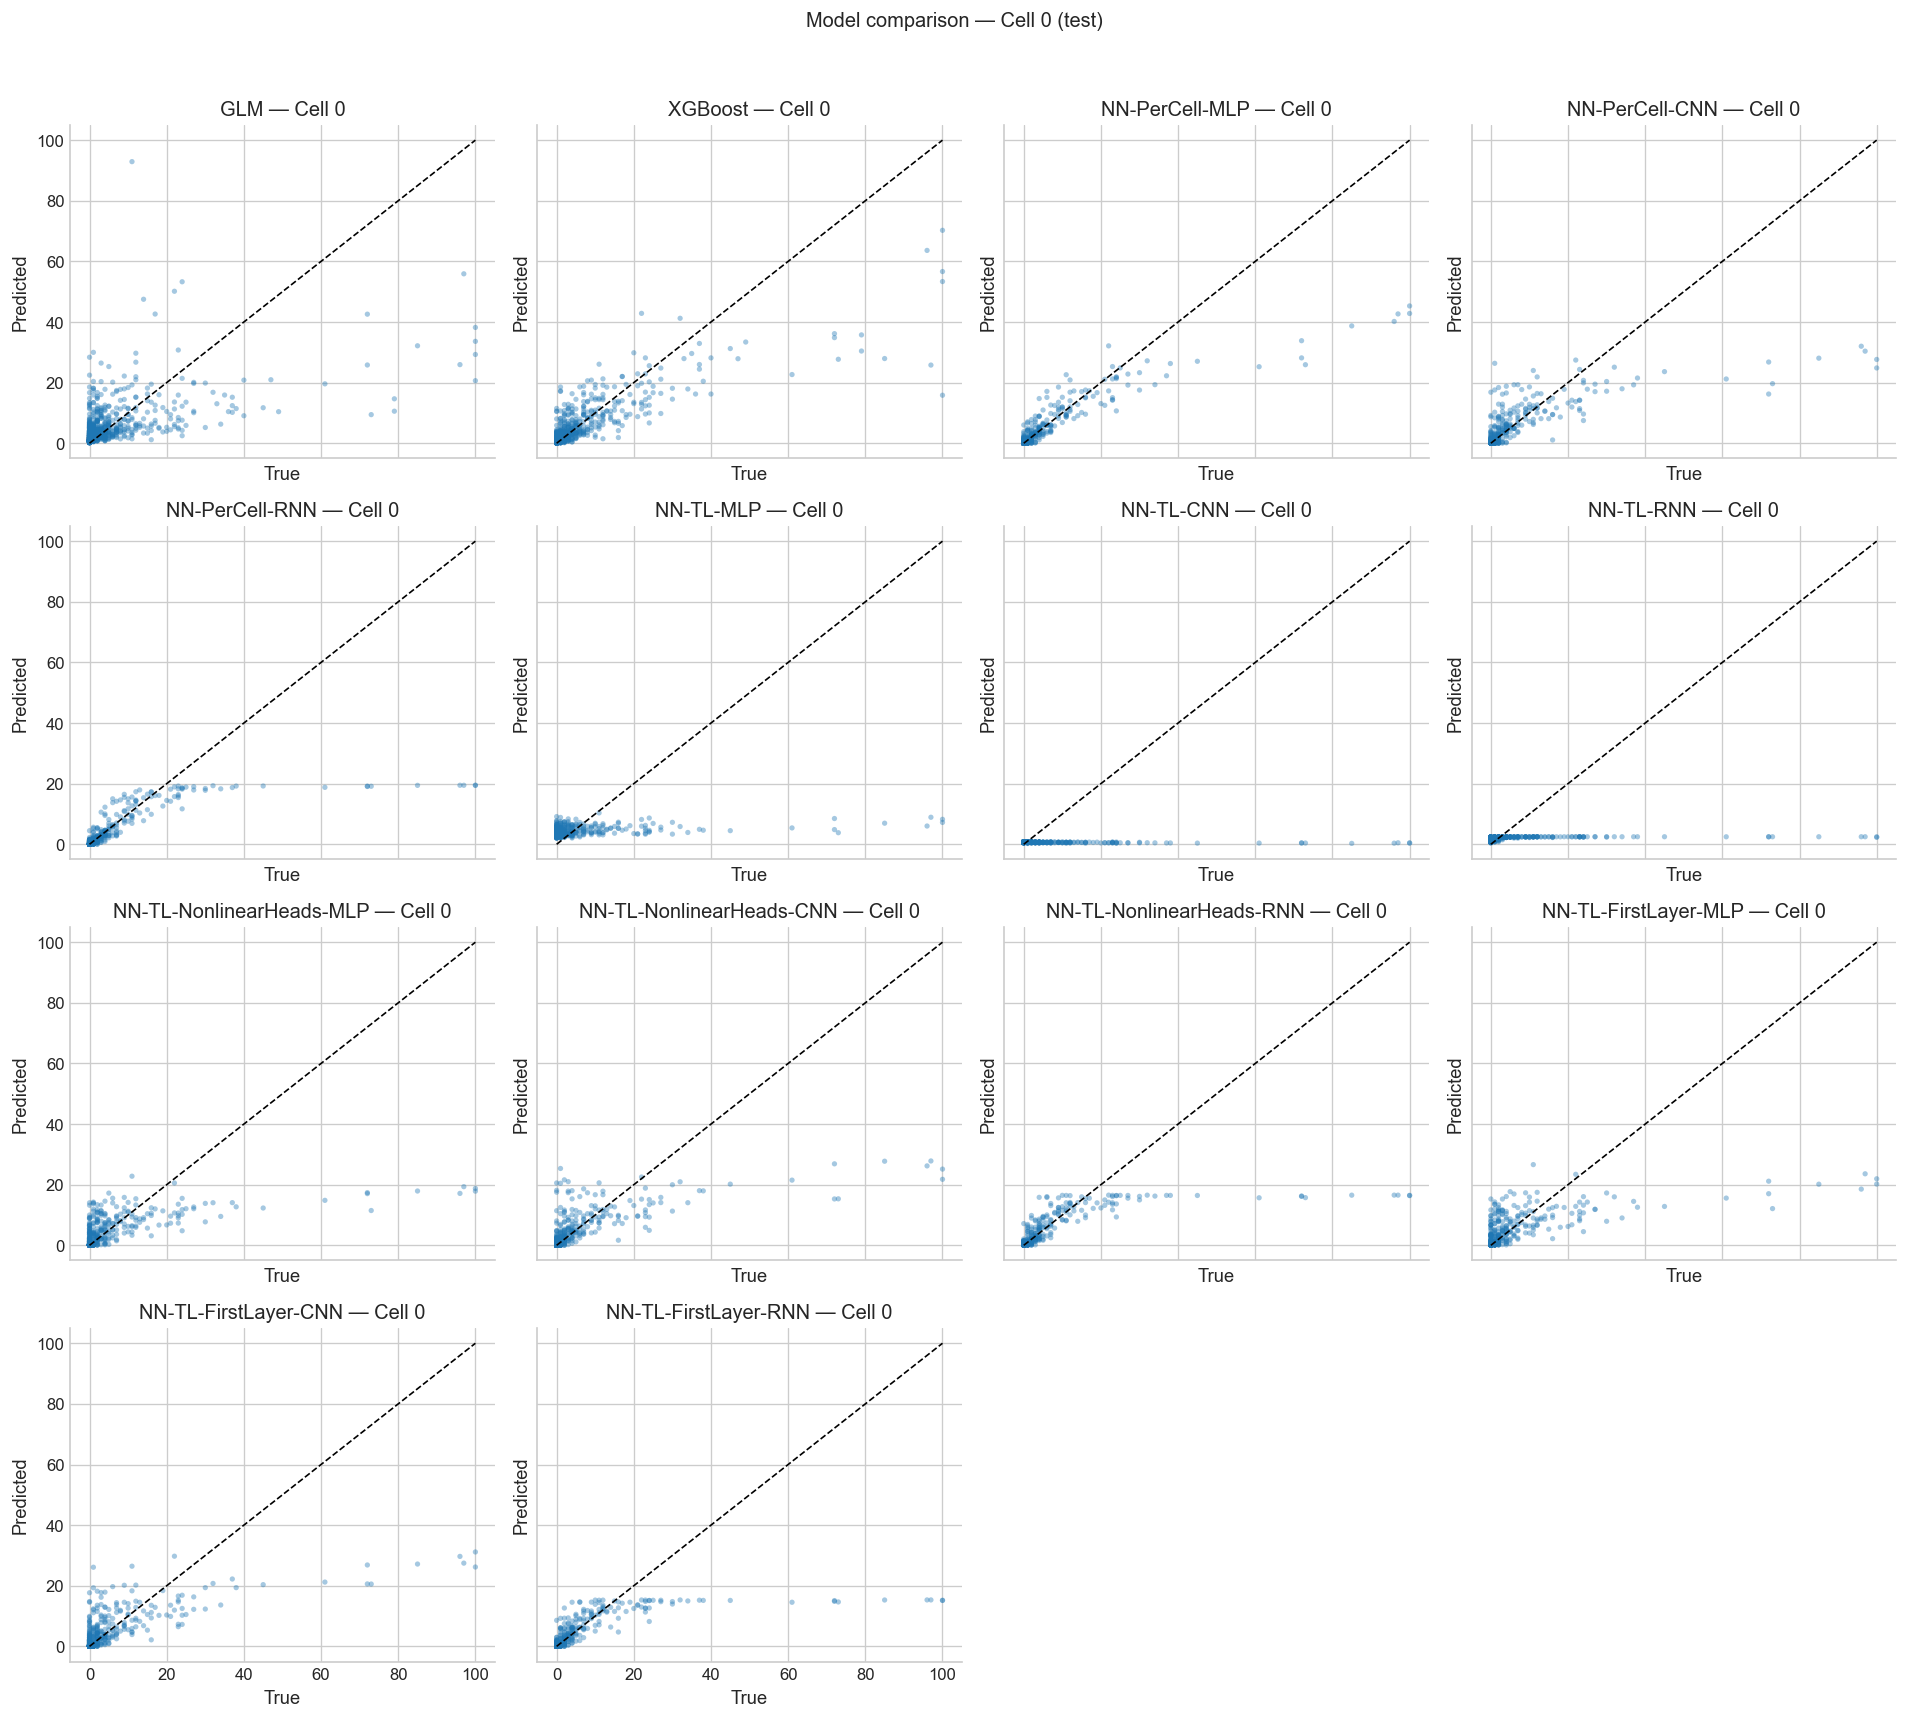

In [ ]:
compare_models_for_cell(model_results_gs, cell=0, split="test")

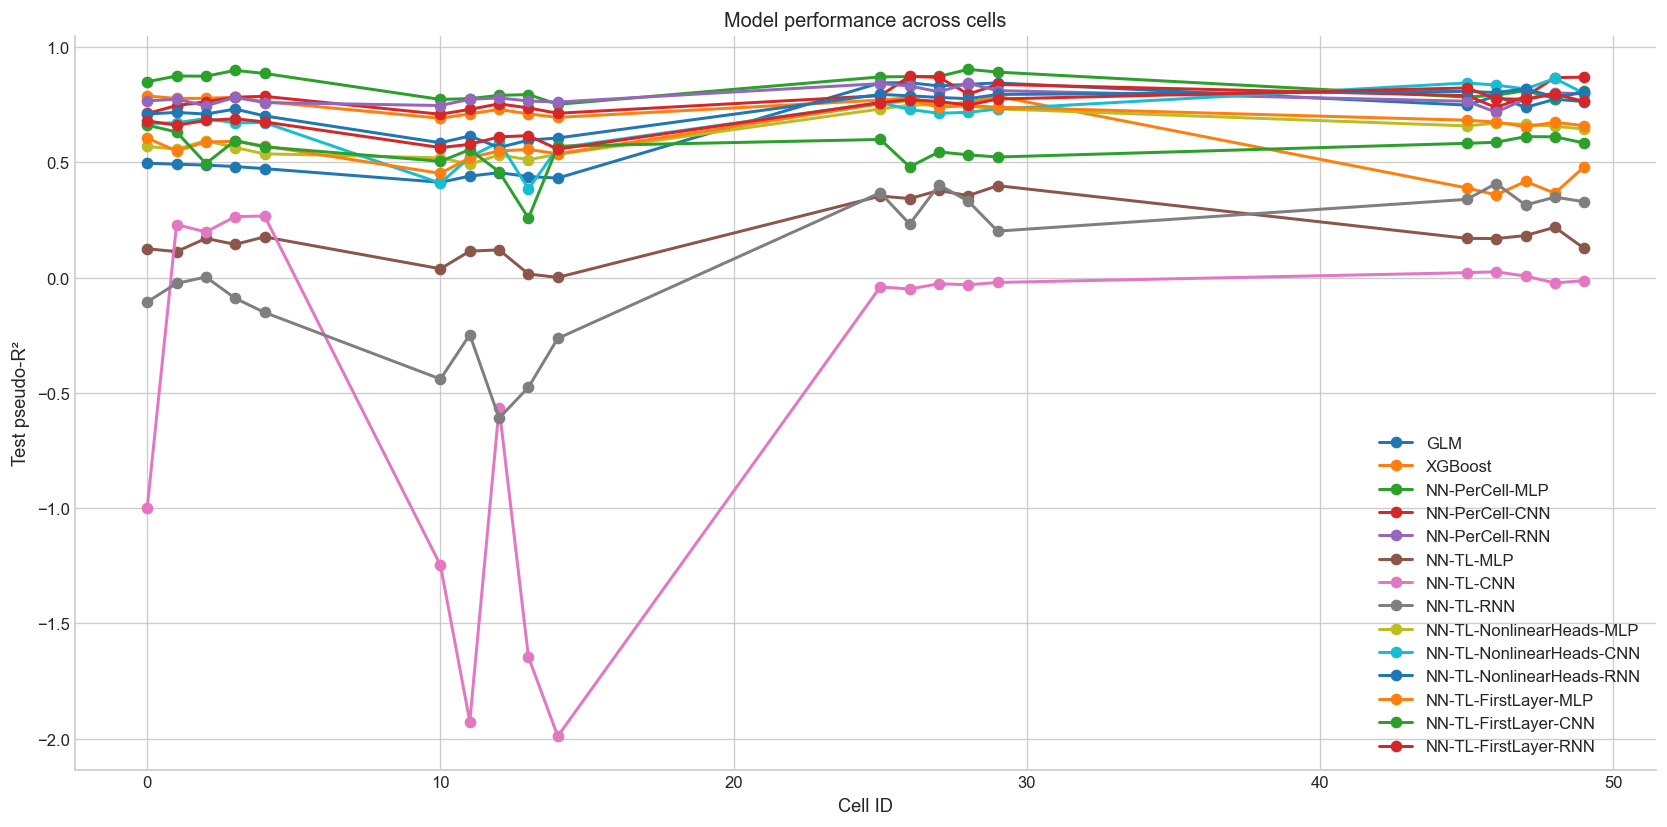

In [ ]:
compare_r2_across_cells(model_results_gs, split="test")

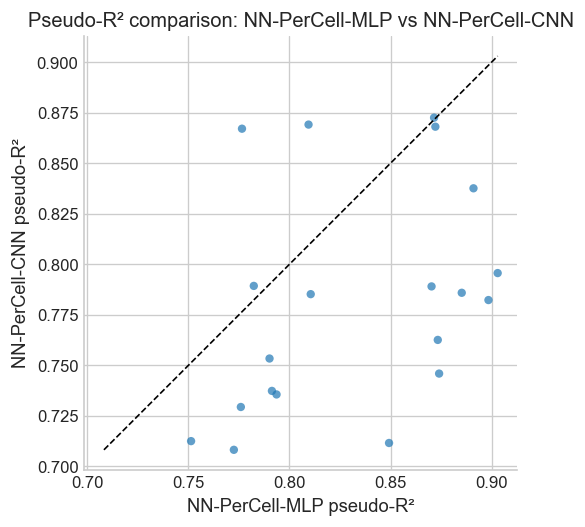

In [ ]:
compare_models_pairwise_r2(
    model_results_gs,
    "NN-PerCell-MLP",
    "NN-PerCell-CNN",
)

In [ ]:
# No-grid-search results for all models
model_results_nogs = [
    (glm_nogs_results["results"], "GLM (No GS)"),
    (xgboost_nogs_results["results"], "XGBoost (No GS)"),
    (percell_results["MLP"]["NoGS"]["results"], "NN-PerCell-MLP (No GS)"),
    (percell_results["CNN"]["NoGS"]["results"], "NN-PerCell-CNN (No GS)"),
    (percell_results["RNN"]["NoGS"]["results"], "NN-PerCell-RNN (No GS)"),
    (tl_results["shared_hidden"]["MLP"]["NoGS"]["results"], "NN-TL-MLP (No GS)"),
    (tl_results["shared_hidden"]["CNN"]["NoGS"]["results"], "NN-TL-CNN (No GS)"),
    (tl_results["shared_hidden"]["RNN"]["NoGS"]["results"], "NN-TL-RNN (No GS)"),
    (
        tl_results["shared_nonlinear_heads"]["MLP"]["NoGS"]["results"],
        "NN-TL-NonlinearHeads-MLP (No GS)",
    ),
    (
        tl_results["shared_nonlinear_heads"]["CNN"]["NoGS"]["results"],
        "NN-TL-NonlinearHeads-CNN (No GS)",
    ),
    (
        tl_results["shared_nonlinear_heads"]["RNN"]["NoGS"]["results"],
        "NN-TL-NonlinearHeads-RNN (No GS)",
    ),
    (
        tl_results["shared_first_layer"]["MLP"]["NoGS"]["results"],
        "NN-TL-FirstLayer-MLP (No GS)",
    ),
    (
        tl_results["shared_first_layer"]["CNN"]["NoGS"]["results"],
        "NN-TL-FirstLayer-CNN (No GS)",
    ),
    (
        tl_results["shared_first_layer"]["RNN"]["NoGS"]["results"],
        "NN-TL-FirstLayer-RNN (No GS)",
    ),
]

cells_nogs = sorted(glm_nogs_results["results"].keys())

In [ ]:
data_rows = []
for cell in cells_nogs:
    row = {"cell": cell}
    for results, name in model_results_nogs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_nogs = pd.DataFrame(data_rows)
df_test_perf_nogs

,cell,GLM (No GS),XGBoost (No GS),NN-PerCell-MLP (No GS),NN-PerCell-CNN (No GS),NN-PerCell-RNN (No GS),NN-TL-MLP (No GS),NN-TL-CNN (No GS),NN-TL-RNN (No GS),NN-TL-NonlinearHeads-MLP (No GS),NN-TL-NonlinearHeads-CNN (No GS),NN-TL-NonlinearHeads-RNN (No GS),NN-TL-FirstLayer-MLP (No GS),NN-TL-FirstLayer-CNN (No GS),NN-TL-FirstLayer-RNN (No GS)
0,0.0,0.495828,0.787478,0.885065,0.709020,0.815604,0.099685,-0.004571,0.000553,0.527575,-0.003017,0.246122,0.508074,0.006070,0.212528
1,1.0,0.491330,0.776923,0.875486,0.737432,0.764460,0.151278,-0.000437,-0.030609,0.507054,-0.001077,0.285311,0.499456,0.008241,0.217865
2,2.0,0.487759,0.777255,0.830839,0.753522,0.762199,0.171046,0.000810,-0.009359,0.506027,0.001802,0.249209,0.491832,0.009156,0.236472
3,3.0,0.481392,0.781882,0.852758,0.771015,0.768709,0.149685,-0.007091,-0.062168,0.517323,-0.008260,0.249537,0.497725,0.002282,0.214325
4,4.0,0.472272,0.763104,0.877682,0.769509,0.766451,0.165163,-0.003726,-0.038029,0.529651,-0.002612,0.255750,0.509045,0.006137,0.240380
5,10.0,0.413206,0.690789,0.773115,0.675075,0.770457,0.053357,-0.068370,-0.889201,0.435092,0.032467,0.214662,0.472152,-0.003300,0.105827
6,11.0,0.439885,0.710068,0.784545,0.682843,0.770170,0.101632,-0.022942,-0.630101,0.479690,0.038317,0.184645,0.458186,0.013526,0.134168
7,12.0,0.454806,0.729184,0.806619,0.701413,0.780624,0.049660,-0.028675,-0.727774,0.491499,0.039686,0.195130,0.463096,0.001291,0.088578
8,13.0,0.438039,0.709677,0.802178,0.702735,0.767803,0.110690,-0.030576,-0.819256,0.477836,0.040187,0.198121,0.486865,0.006496,0.117714
9,14.0,0.431220,0.694672,0.770355,0.667336,0.754030,0.098987,-0.019416,-0.807740,0.495112,0.046852,0.198691,0.484243,0.010680,0.118277


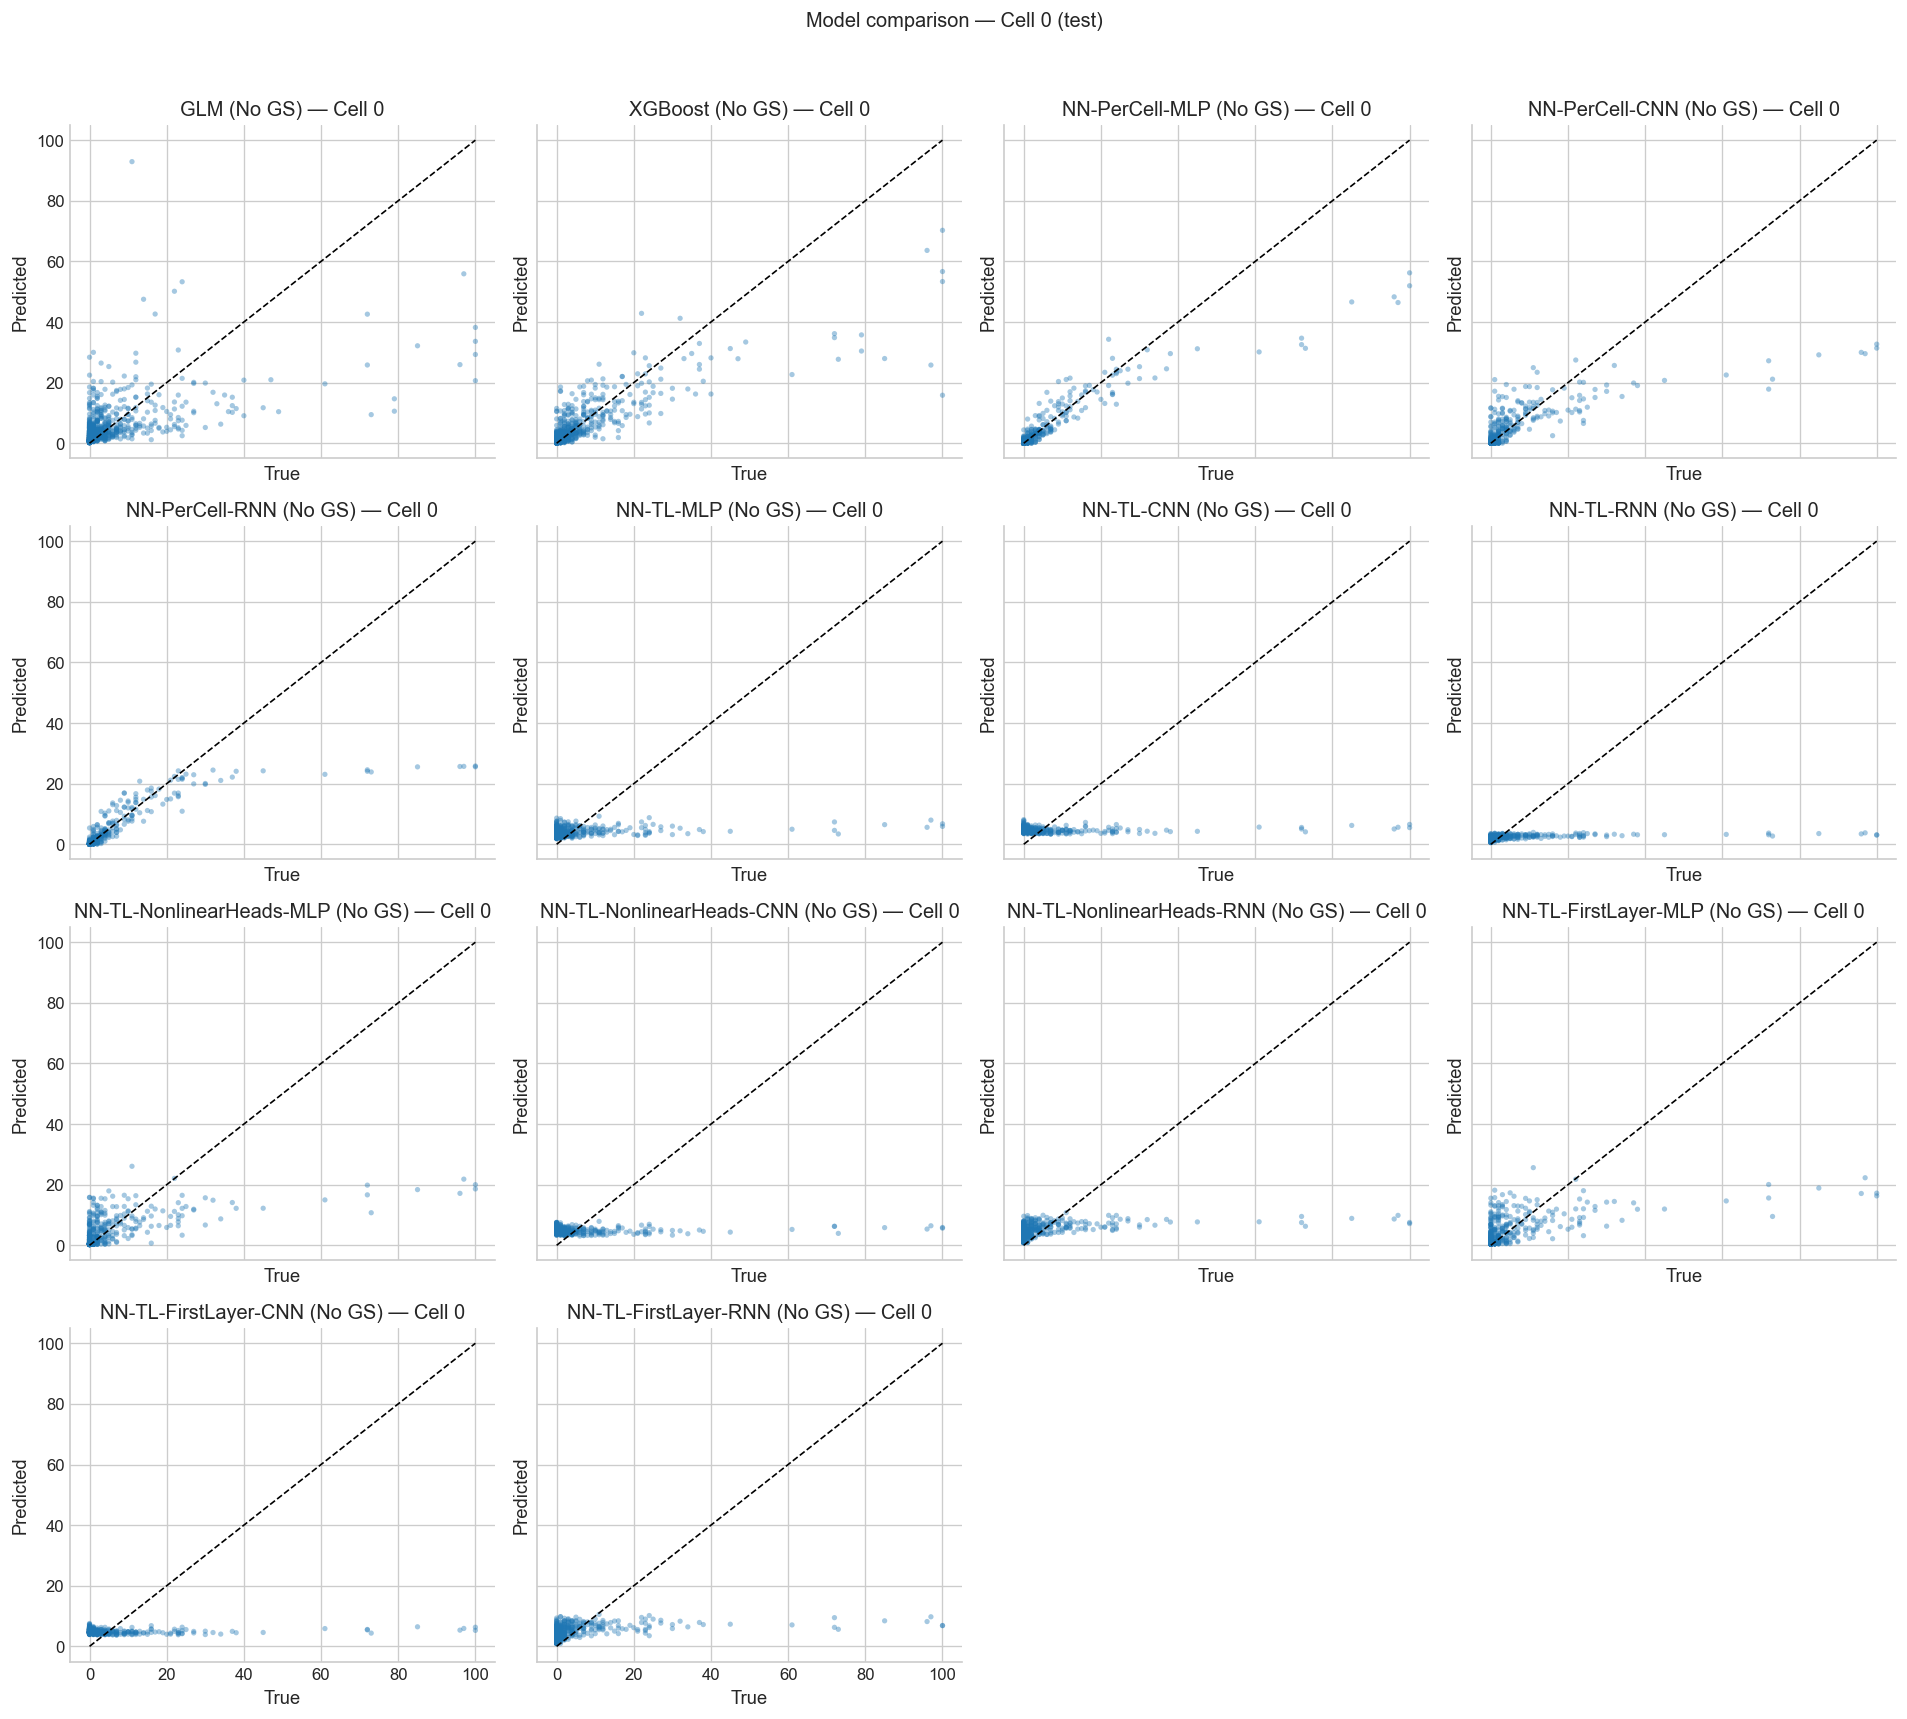

In [ ]:
compare_models_for_cell(model_results_nogs, cell=0, split="test")

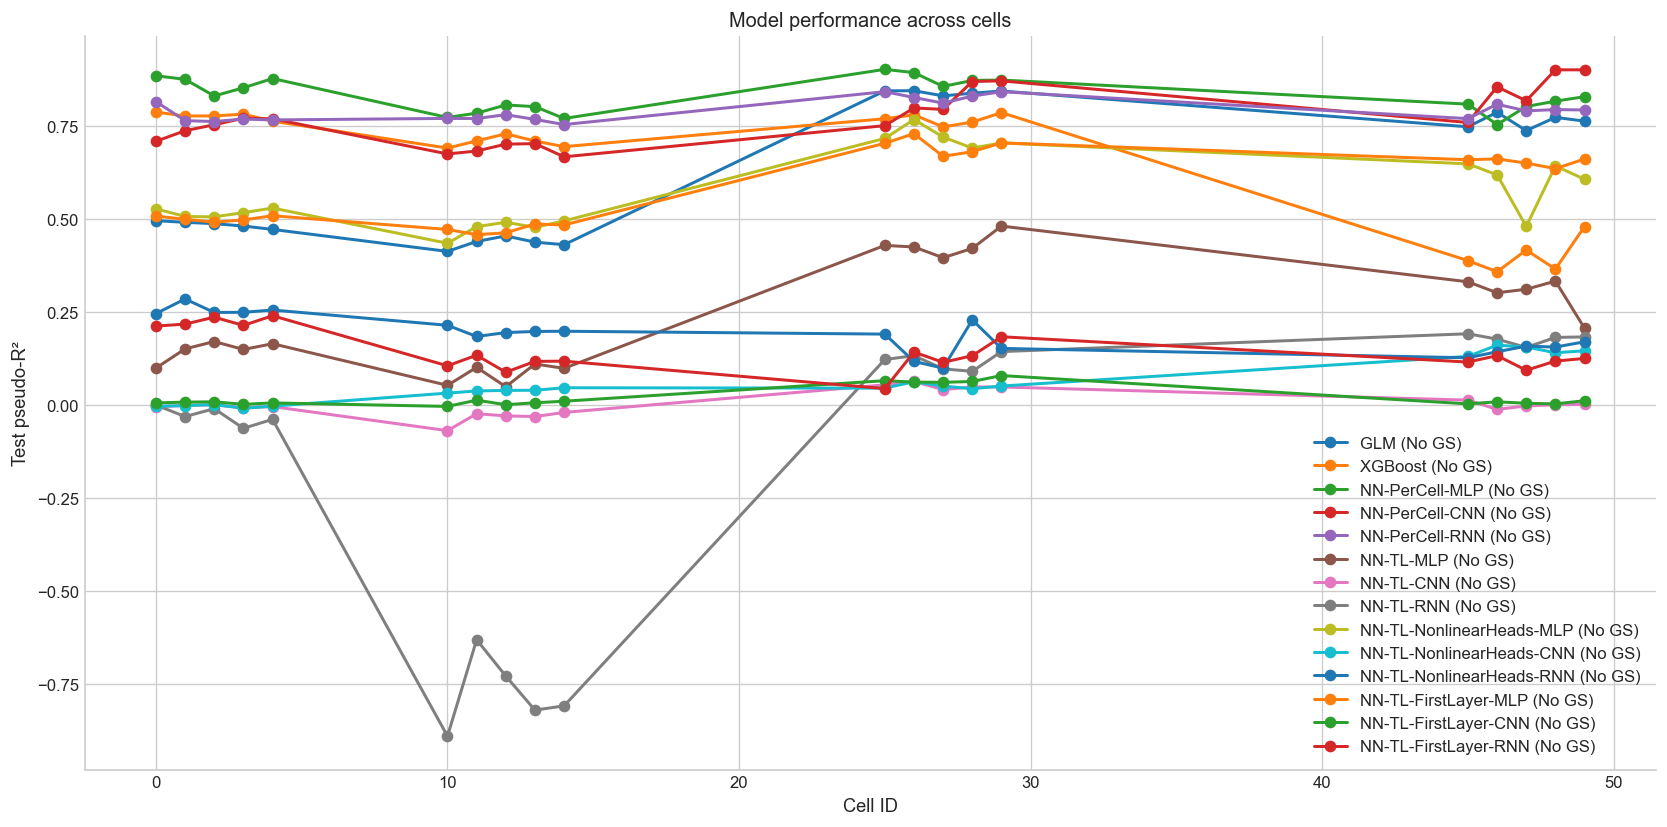

In [ ]:
compare_r2_across_cells(model_results_nogs, split="test")

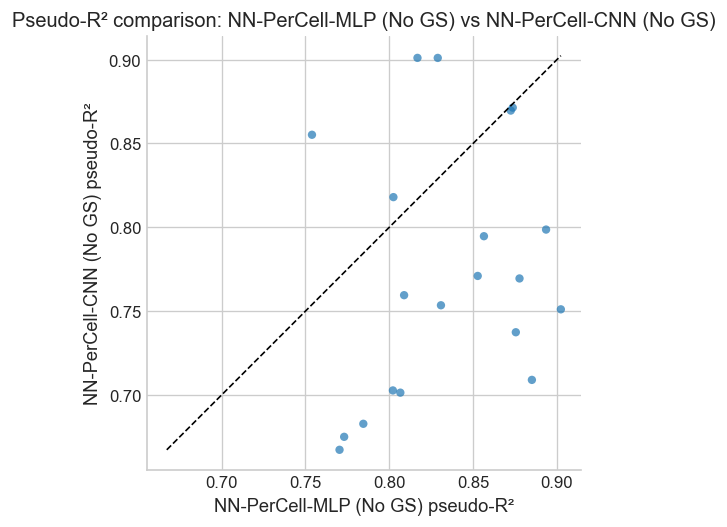

In [ ]:
compare_models_pairwise_r2(
    model_results_nogs,
    "NN-PerCell-MLP (No GS)",
    "NN-PerCell-CNN (No GS)",
)

In [ ]:
saved_paths = journal_plot_pack(
    model_results_gs,
    cells=cells_gs,
    split="test",
    base_dir=BASE_RESULTS_DIR,
)
print(f"Generated {len(saved_paths)} plots")
for p in saved_paths[-5:]:
    print(f"  {p}")

Generated 112 plots
  ..\resources\results\simulated\journal\pairwise_NN-TL-NonlinearHeads-RNN_vs_NN-TL-FirstLayer-CNN.png
  ..\resources\results\simulated\journal\pairwise_NN-TL-NonlinearHeads-RNN_vs_NN-TL-FirstLayer-RNN.png
  ..\resources\results\simulated\journal\pairwise_NN-TL-FirstLayer-MLP_vs_NN-TL-FirstLayer-CNN.png
  ..\resources\results\simulated\journal\pairwise_NN-TL-FirstLayer-MLP_vs_NN-TL-FirstLayer-RNN.png
  ..\resources\results\simulated\journal\pairwise_NN-TL-FirstLayer-CNN_vs_NN-TL-FirstLayer-RNN.png
